In [2]:
%matplotlib inline

In [3]:
from music21 import converter, note, chord, stream, interval, key, repeat
import os.path
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def splitMeasures(filepath):
    '''Takes a MusicXML file and splits it into measures.

    Inputs:
        filepath - path to XML file

    Outputs:
        measureList - list of dictionaries, each dictionary contains:
                      - measure_number: int
                      - notes: list of note dictionaries with pitch, midi, start, duration, voice, and staff
        time_signature - tuple (numerator, denominator)
    '''
    from music21 import converter, stream, note, chord

    # Parse the MusicXML file
    original_score = converter.parse(filepath)

    # Extract time signature before any modifications
    ts_obj = original_score.recurse().getElementsByClass('TimeSignature')[0]
    if ts_obj.symbol == 'common':
        time_signature = (4, 4)
    else:
        time_signature = (ts_obj.numerator, ts_obj.denominator)

    # Use music21's built-in method to expand repeats without the invalid copyAll parameter
    expanded_score = original_score.expandRepeats()

    measures_data = {}
    
    # Process each part in the expanded score
    for part in expanded_score.parts:
        part_measures = list(part.getElementsByClass(stream.Measure))
        
        for i, measure in enumerate(part_measures):
            # Use sequential indexing (1-based) for expanded measures
            measure_number = i + 1
            
            if measure_number not in measures_data:
                measures_data[measure_number] = []

            # Process all notes and rests in the measure
            for element in measure.recurse().notesAndRests:
                voice = element.getContextByClass('Voice')
                staff = element.getContextByClass('Staff')
                voice_num = voice.id if voice else None
                staff_num = staff.number if staff else None

                if isinstance(element, note.Note):
                    measures_data[measure_number].append({
                        'pitch': element.pitch.nameWithOctave,
                        'midi': element.pitch.midi,
                        'start': float(element.offset),
                        'duration': float(element.quarterLength),
                        'voice': voice_num,
                        'staff': staff_num
                    })

                elif isinstance(element, chord.Chord):
                    for n in element.notes:
                        measures_data[measure_number].append({
                            'pitch': n.pitch.nameWithOctave,
                            'midi': n.pitch.midi,
                            'start': float(element.offset),
                            'duration': float(element.quarterLength),
                            'voice': voice_num,
                            'staff': staff_num
                        })

    measureList = [
        {'measure_number': num, 'notes': measures_data[num]}
        for num in sorted(measures_data)
    ]

    return measureList, time_signature

In [5]:
def notesToMatrix(measureList, time_signature, repeat_frames = True, onset_model=False):

    roll = []

    (beats, note_type) = time_signature

    framesperquarter = 16
    expected_duration = beats * (4 / note_type)
    expected_frames = int(expected_duration * framesperquarter)
    notes = 88 # keys on a piano

    for i, measure in enumerate(measureList):
        # Compute actual content length of measure
        if measure['notes']:
            content_end = max((n['start'] + n['duration']) for n in measure['notes'] if n['duration'] > 0)
        else:
            content_end = 0.0

        if i == 0 and content_end < expected_duration:
            # This is likely a pickup measure
            frames = int(np.ceil(content_end * framesperquarter))
        else:
            # Full measure
            frames = expected_frames

        arr = np.zeros((notes, frames))

        for note in measure['notes']:
            midi = note['midi']
            keyIndex = midi - 20 # uncomment if want piano keys instead of midi
            start = int(note['start']*framesperquarter)
            duration = note['duration'] if note['duration'] > 0 else (1/note_type)/4
            end = start + int(duration*framesperquarter)

            if onset_model:
                end = start + 1

            if 0 <= keyIndex < notes and start < frames:
                arr[keyIndex, start:min(end, frames)] = 1

        roll.append(arr)

    if not repeat_frames:
        unique_roll = []
        for measure in roll:
            _, idx = np.unique(measure.T, axis=0, return_index=True)
            unique_cols = measure[:, np.sort(idx)]
            unique_roll.append(unique_cols)
        roll = unique_roll


    return roll

In [6]:
def getMeasureBoundaries(roll):
     """
     Get boundaries for each measure in terms of frames
     """
     boundaries = []
     boundaries = np.zeros(len(roll), dtype=int)

     for i in range(len(roll)):
         boundary = roll[i].shape[1] + boundaries[i-1]
         boundaries[i] = boundary

     return boundaries

In [27]:
dir = 'xml'
# file = 'bach_fugue_bwv_846.musicxml'
file = 'schumann_arabeske.musicxml'
# file = 'glinka.musicxml'
# file = 'brahms.musicxml'
# file = 'liszt_concert_etude_s145_1.musicxml'
# file = 'Mozart-Fantasie.musicxml'
# file = 'debussy.musicxml'
# file = 'Chopin-Ballades-1.musicxml'
# file = 'Haydn-6-1.musicxml'
# file = 'Prokofiev-Toccata.musicxml'
# file = 'Beethovem-30-1.musicxml'
# file = 'Ravel.musicxml'
filepath = os.path.join(dir, file)

measureList, time_signature = splitMeasures(filepath)

In [44]:
roll = notesToMatrix(measureList, time_signature, repeat_frames = True, onset_model=False)
measure_boundaries = (getMeasureBoundaries(roll))
full_roll = np.concatenate(roll, axis=1) # Concatenate roll to single np matrix

print(measure_boundaries)

[  20   52   84  116  148  180  212  244  276  308  340  372  404  436
  468  500  532  564  596  628  660  692  724  756  788  820  852  884
  916  948  980 1012 1044 1076 1108 1140 1172 1204 1236 1268 1300 1332
 1364 1396 1428 1460 1492 1524 1556 1588 1620 1652 1684 1716 1748 1780
 1812 1844 1876 1908 1940 1972 2004 2036 2068 2100 2132 2164 2196 2228
 2260 2292 2324 2356 2388 2420 2452 2484 2516 2548 2580 2612 2644 2676
 2708 2740 2772 2804 2836 2868 2900 2932 2964 2996 3028 3060 3092 3124
 3156 3188 3220 3252 3284 3316 3348 3380 3412 3444 3476 3508 3540 3572
 3604 3636 3668 3700 3732 3764 3796 3828 3860 3892 3924 3956 3988 4020
 4052 4084 4116 4148 4180 4212 4244 4276 4308 4340 4372 4404 4436 4468
 4500 4532 4564 4596 4628 4660 4692 4724 4756 4788 4820 4852 4884 4916
 4948 4980 5012 5044 5076 5108 5140 5172 5204 5236 5268 5300 5332 5364
 5396 5428 5460 5492 5524 5556 5588 5620 5652 5684 5716 5748 5780 5812
 5844 5876 5908 5940 5972 6004 6036 6068 6100 6132 6164 6196 6228 6260
 6292 

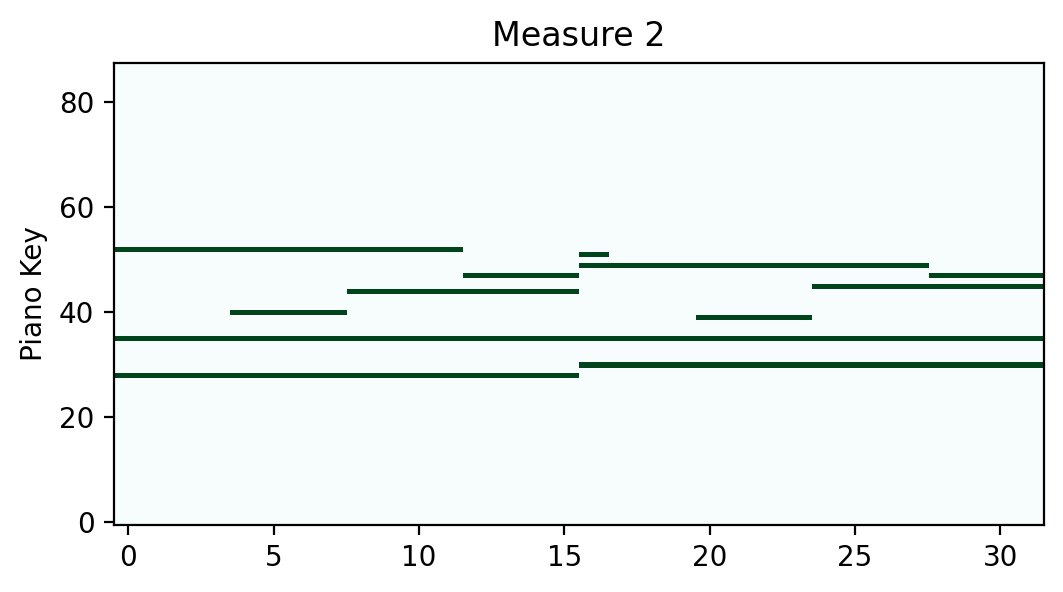

In [45]:
measure_number = 2

plt.figure(figsize=(6,3))
plt.imshow(roll[measure_number-1], cmap = 'BuGn', origin = 'lower', aspect='auto')
plt.title(f'Measure {measure_number}')
plt.ylabel('Piano Key')
plt.show()

In [46]:
# np.savez(os.path.join('onset_xml_features', 'onset' + file), roll=full_roll, measure_boundaries=measure_boundaries)
# np.savez(os.path.join('xml_features', file), roll=full_roll, measure_boundaries=measure_boundaries)
# np.savez(os.path.join('unique_xml_features', 'unique'+file), roll=full_roll, measure_boundaries=measure_boundaries)

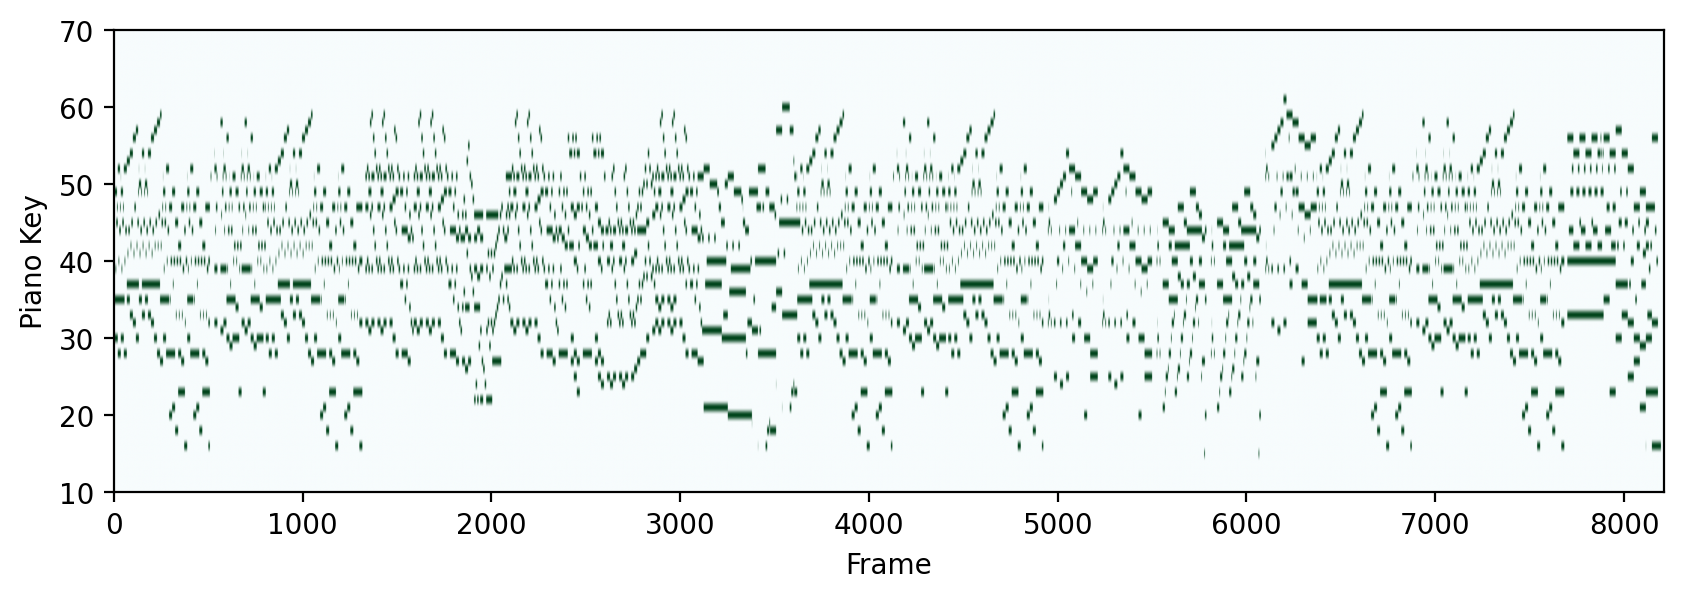

In [51]:
plt.figure(figsize=(10,3))
plt.imshow(full_roll, cmap = 'BuGn', origin = 'lower', aspect='auto', interpolation=None)
plt.ylabel('Piano Key')
plt.xlabel('Frame')
plt.ylim([10,70])
plt.show()